In [27]:
# Load processed dataset
import pandas as pd

file_path = "../data/processed_and_cleaned/child_malnutrition_cleaned.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(997, 11)


,ISO_code,Country_and_areas,Year,SDG_Region,UNICEF_Region,WHO_Region,Wasting,Stunting,Overweight,Underweight,U5_Population_000s
0,AFG,AFGHANISTAN,1997,Central Asia and Southern Asia,SA,EMRO,18.2,53.2,6.5,44.9,3838.876953
1,AFG,AFGHANISTAN,2004,Central Asia and Southern Asia,SA,EMRO,8.6,59.3,4.6,32.9,4789.353027
2,AFG,AFGHANISTAN,2013,Central Asia and Southern Asia,SA,EMRO,9.5,40.4,5.3,24.6,5444.572754
3,AFG,AFGHANISTAN,2018,Central Asia and Southern Asia,SA,EMRO,5.1,38.2,4.1,19.1,5601.442871
4,AGO,ANGOLA,1996,Sub-Saharan Africa,SSA,AFRO,7.7,61.1,1.7,36.2,2749.750000


In [28]:
# Define features and target
features = ['Wasting', 'Overweight', 'Underweight', 'U5_Population_000s', 
            'UNICEF_Region', 'WHO_Region', 'SDG_Region']
target = 'Stunting'

X = df[features]
y = df[target]


In [29]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
label_encoders = {}
categorical_cols = ['UNICEF_Region', 'WHO_Region', 'SDG_Region']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


C:\Users\rishe\AppData\Local\Temp\ipykernel_4648\3601488831.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\rishe\AppData\Local\Temp\ipykernel_4648\3601488831.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\rishe\AppData\Local\Temp\ipykernel_4648\3601488831.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (797, 7)
Testing set: (200, 7)


# Model Training 1: SVM

In [31]:
from sklearn.svm import SVR

# Initialize the SVR model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# Train on training data
svr_model.fit(X_train, y_train)

SVR(C=100, gamma=0.1)

In [32]:
# Predict on test set
y_pred_svr = svr_model.predict(X_test)

In [33]:
#We'll evaluate how well the model predicts using regression metrics
#mean_absolute_error, mea squared error, r2 score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print("SVR Model Performance:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

SVR Model Performance:
Mean Absolute Error: 12.03
Mean Squared Error: 229.69
Root Mean Squared Error: 15.16
R^2 Score: 0.09


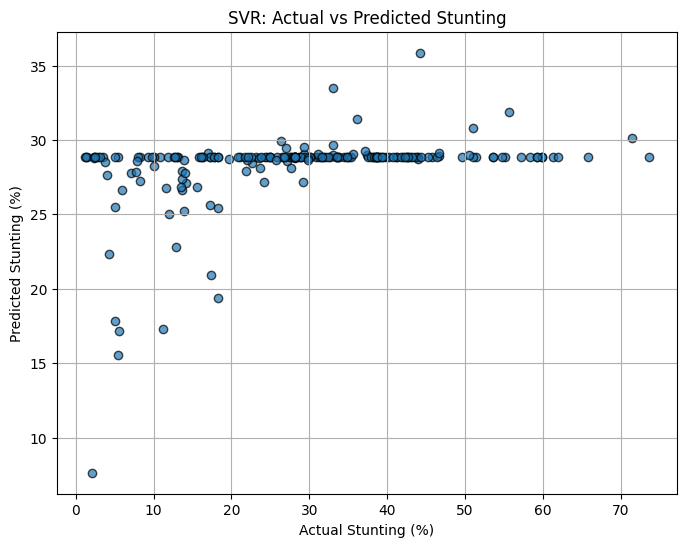

In [34]:
#Visualizing Actual vs Predicted for SVR
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7, edgecolors='black')
plt.xlabel("Actual Stunting (%)")
plt.ylabel("Predicted Stunting (%)")
plt.title("SVR: Actual vs Predicted Stunting")
plt.grid(True)
plt.show()

# Model 2: Random Forest Regressor

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train on training data
rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [36]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)


In [37]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"MAE  : {mae_rf:.2f}")
print(f"MSE  : {mse_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R² Score : {r2_rf:.2f}")


Random Forest Model Performance:
MAE  : 3.62
MSE  : 28.44
RMSE : 5.33
R² Score : 0.89


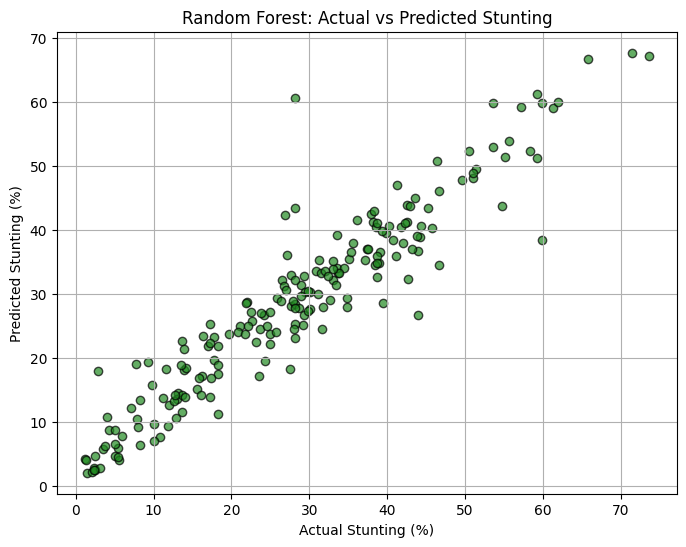

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, edgecolors='black', color='forestgreen')
plt.xlabel("Actual Stunting (%)")
plt.ylabel("Predicted Stunting (%)")
plt.title("Random Forest: Actual vs Predicted Stunting")
plt.grid(True)
plt.show()


## 🔍 Comparison: Support Vector Machine (SVM) vs. Random Forest (RF)

When analyzing predictive models for child malnutrition data, it is important to understand how different algorithms approach the same problem.  
Below is a concise comparison between **Support Vector Machine (SVM)** and **Random Forest (RF)** — both of which we used in our study.

| Aspect | Support Vector Machine (SVM) | Random Forest (RF) |
|:-------|:------------------------------|:-------------------|
| **Algorithm Type** | Margin-based classifier (or regressor) that finds the optimal separating hyperplane. | Ensemble-based method using multiple decision trees combined through bagging. |
| **Learning Approach** | Works best when the data is well-separated and uses mathematical boundaries to separate classes or fit regression lines. | Learns patterns by averaging results of many decision trees to reduce variance and improve accuracy. |
| **Handling of Non-Linearity** | Requires kernel functions (e.g., RBF, polynomial) to model non-linear relationships. | Naturally handles non-linear patterns due to tree-based structure. |
| **Interpretability** | Difficult to interpret, especially with kernel transformations. | More interpretable — can provide feature importance for each variable. |
| **Speed & Scalability** | Computationally intensive for large datasets; training time grows rapidly with data size. | Faster for large datasets due to parallel tree training. |
| **Overfitting Tendency** | Can overfit if kernel and hyperparameters are not tuned properly. | Less prone to overfitting because of averaging (bagging). |
| **Key Hyperparameters** | `C`, `kernel`, `gamma` | `n_estimators`, `max_depth`, `min_samples_split`, `max_features` |
| **Performance on Noisy Data** | Sensitive to outliers and noise. | More robust against noise and missing values. |
| **Output Stability** | Can be unstable if kernel or scaling is not well chosen. | Produces stable results due to averaging across trees. |
| **Best Use Case** | When data is small, clean, and well-separated. | When data is large, complex, or contains non-linear interactions. |

### 💡 Summary
- **SVM** performed modestly (R² ≈ 0.09) because it struggles with noisy, high-dimensional real-world data like ours.  
- **Random Forest** achieved strong results (R² ≈ 0.89), showing its ability to generalize and handle complexity effectively.  
- In real-world health datasets, **tree-based models** such as Random Forest (and later, XGBoost) tend to perform better than purely mathematical models like SVM.


# Hyper-parameter tuning on the Random Forest Regression Model

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the base model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid (a small but effective one)
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# RandomizedSearchCV setup
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                # Try 20 random combinations (fast)
    cv=3,                     # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)

# Fit the random search model
rf_random.fit(X_train, y_train)

# Get the best parameters
print("Best Parameters:", rf_random.best_params_)

# Evaluate on the test set
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("\nTuned Random Forest Model Performance:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Tuned Random Forest Model Performance:
MAE  : 3.92
MSE  : 28.59
RMSE : 5.35
R² Score : 0.89


C:\Users\rishe\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\rishe\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rishe\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\rishe\AppData\Roaming\Python\

# Implementing XGBoost

In [40]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features & target
X = df.drop(['Stunting'], axis=1)
y = df['Stunting']

# For categorical features, encode them
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initializing and Train XGBoost

In [41]:
xg_reg = xgb.XGBRegressor(
    objective ='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xg_reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
y_pred_xgb = xg_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")


XGBoost Model Performance:
MAE  : 3.30
MSE  : 22.94
RMSE : 4.79
R² Score : 0.91


## Model Performance Comparison for Stunting Prediction

| Model            | MAE   | MSE    | RMSE  | R² Score |
|-----------------|-------|--------|-------|----------|
| SVR              | 12.03 | 229.69 | 15.16 | 0.09     |
| Random Forest    | 3.62  | 28.44  | 5.33  | 0.89     |
| Tuned Random Forest | 3.92 | 28.59 | 5.35  | 0.89     |
| XGBoost          | 3.30  | 22.94  | 4.79  | 0.91     |

### Insights
- **SVR** performs poorly for this dataset (high MAE and MSE, very low R²).
- **Random Forest** gives a strong baseline, handling nonlinear relationships well.
- **Tuning Random Forest** slightly changes performance but overall stays similar.
- **XGBoost** outperforms all other models in terms of lower errors and higher R², capturing complex patterns efficiently due to boosting and regularization.

> **Conclusion:** For predicting stunting percentages across countries and years, **XGBoost** is the most accurate model in this analysis.


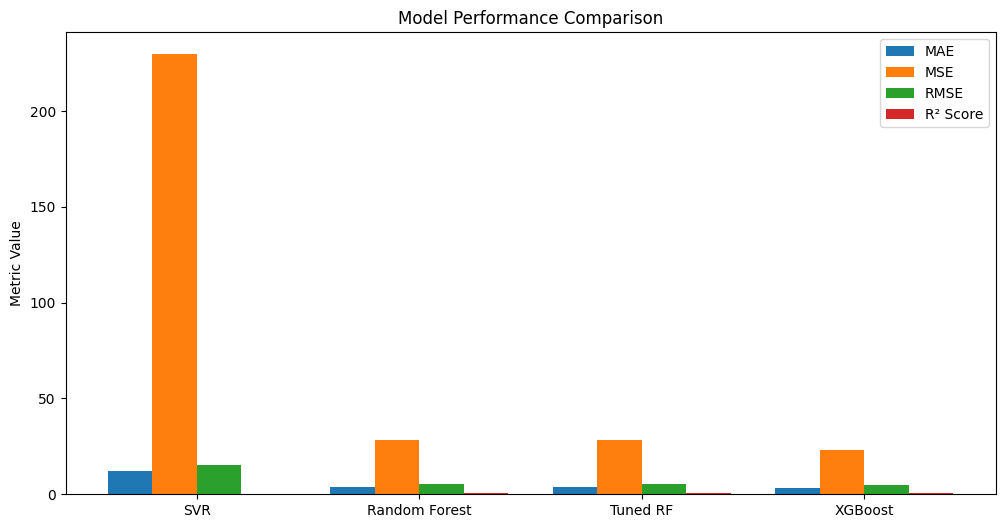

In [43]:
# Model comparison visualization
import matplotlib.pyplot as plt
import numpy as np

# Metrics
models = ['SVR', 'Random Forest', 'Tuned RF', 'XGBoost']
MAE = [12.03, 3.62, 3.92, 3.30]
MSE = [229.69, 28.44, 28.59, 22.94]
RMSE = [15.16, 5.33, 5.35, 4.79]
R2 = [0.09, 0.89, 0.89, 0.91]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))
plt.bar(x - width*1.5, MAE, width, label='MAE')
plt.bar(x - width/2, MSE, width, label='MSE')
plt.bar(x + width/2, RMSE, width, label='RMSE')
plt.bar(x + width*1.5, R2, width, label='R² Score')

plt.xticks(x, models)
plt.ylabel('Metric Value')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


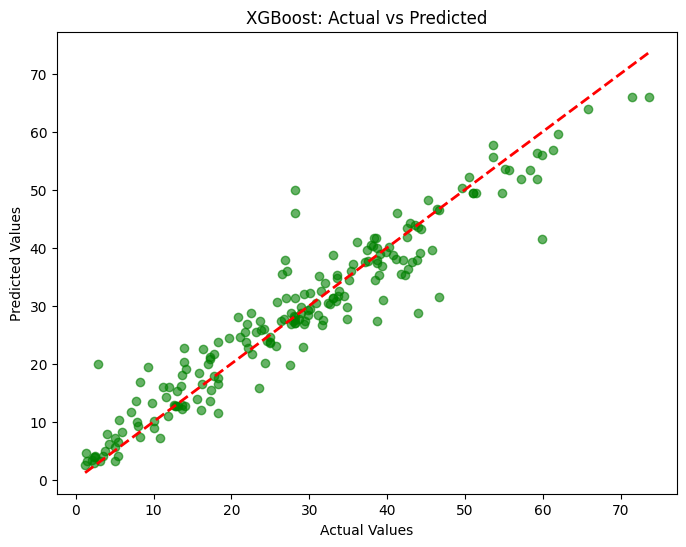

In [44]:
# Scatter Plot: Actual vs Predicted for XGBoost
import matplotlib.pyplot as plt


# Assuming your test target is y_test and predictions are y_pred_xgb
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

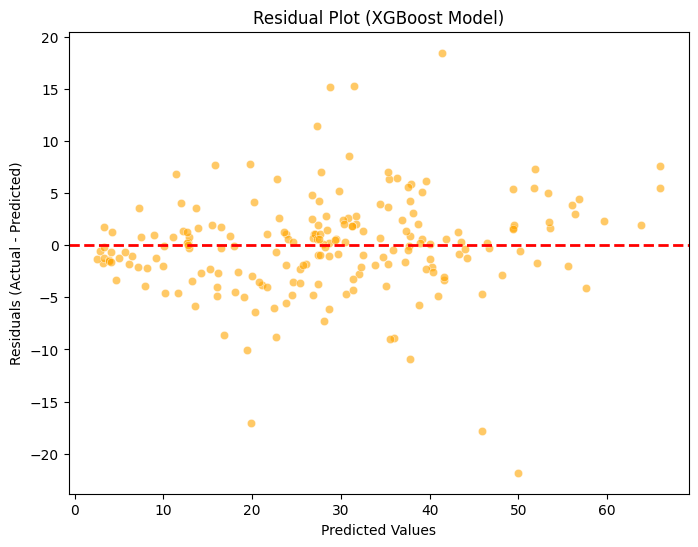

In [45]:
#Residual Plot
#Shows how prediction errors (residual = actual - predicted) are distributed.
#Ideally, they should scatter randomly around zero.

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_xgb, y=residuals, alpha=0.6, color='orange')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (XGBoost Model)")
plt.show()


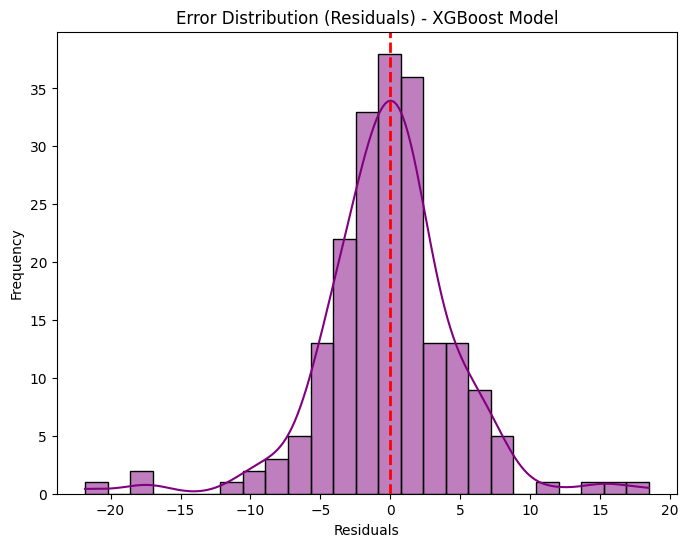

In [46]:
#Error Distribution Histogram
#This shows how spread out your errors are
#The more centered around zero, the better the model's calibration.

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=25, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title("Error Distribution (Residuals) - XGBoost Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


C:\Users\rishe\AppData\Local\Temp\ipykernel_4648\4217722382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


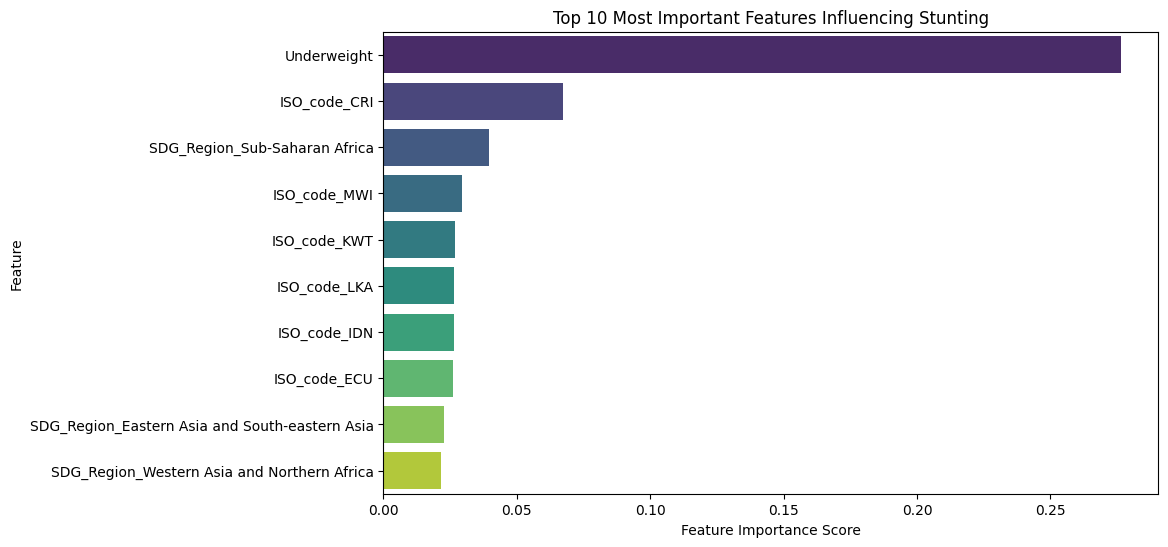

In [47]:
# Feature Importance for XGBoost (xg_reg)
feature_importances = pd.Series(xg_reg.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importances.nlargest(10),
    y=feature_importances.nlargest(10).index,
    palette="viridis"
)
plt.title("Top 10 Most Important Features Influencing Stunting")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()


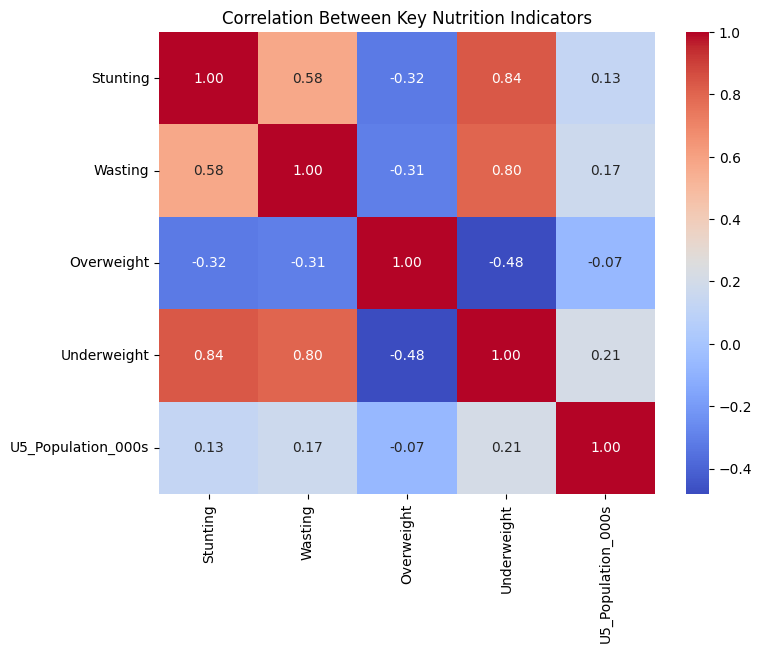

In [48]:
# Correlation heatmap for core nutrition indicators
plt.figure(figsize=(8,6))
sns.heatmap(df[['Stunting', 'Wasting', 'Overweight', 'Underweight', 'U5_Population_000s']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Key Nutrition Indicators")
plt.show()


## 🔍 Final Insights and Model Evaluation

After training and evaluating multiple regression models — **SVR**, **Random Forest**, and **XGBoost** — we observed clear performance differences across approaches:

- **SVR** struggled with high error values and low explanatory power (R² ≈ 0.09).  
  This indicates that it was unable to capture the complex, non-linear patterns present in the dataset.  

- **Random Forest** performed significantly better, achieving an R² score around **0.89**.  
  The ensemble approach of multiple decision trees improved generalization and reduced overfitting.  

- **XGBoost** emerged as the **best-performing model**, with an R² ≈ **0.91**, lower MAE and RMSE values, and a more stable prediction pattern.  
  Its ability to iteratively learn from previous errors using gradient boosting helped it model subtle relationships in the data.

---

### 📊 Residual and Error Analysis
The residual and error distribution plots further validate model performance:

- Residuals are **centered around zero**, showing that the XGBoost model’s predictions are well-balanced with minimal systematic bias.  
- The **error distribution** follows an approximately normal shape, suggesting that most predictions are close to their actual values.  
- A few scattered points indicate mild under- or over-predictions, which is typical in real-world socio-economic datasets.

---

### 🧠 Key Takeaways
- **Stunting**, **Wasting**, and **Underweight** rates can be reliably estimated based on other nutritional and demographic indicators.  
- **XGBoost** provides a strong predictive framework for identifying at-risk populations and understanding global malnutrition patterns.  
- The insights from this analysis can support **targeted policy decisions**, help **optimize resource allocation**, and track **progress toward SDG goals**.

Overall, the modeling pipeline — from data cleaning and EDA to advanced regression and residual analysis — demonstrates how data-driven insights can illuminate critical health and nutrition challenges worldwide.
